In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

plt.style.use("ggplot")

# random traces prob should remove these
trace = "9bc86d6cd1ee254aaa313492f0fd88be8bd7b92d50d4237ff52d7685440c0906"
t2 = "734272c01926d19690e5ec308bab64ef97950b75b1c7582283e0783fce1751d8"

# trace with the highest number of invocations
t_max = "155e47f8e7f751d0c845049456d01832013c61336a8cd85901330ac821a71534"

df = pd.read_csv(
    "data/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
)


#df["end_timestamp"] = pd.to_timedelta(df["end_timestamp"], unit="seconds")
df["start_timestamp"] = df["end_timestamp"] - df["duration"]
df

/Users/jori/Projects/thesis/thesis-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,app,func,end_timestamp,duration,start_timestamp
0,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,e3cdb48830f66eb8689cc0223514569a69812b77e6611e...,7.949090e-02,0.078,1.490900e-03
1,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,337cd24a7d5fd5c92460faee4ebe6a186a0eb322bd17b7...,5.715786e+01,57.154,3.860041e-03
2,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,48cc770d590d3c5a7691b3b4e9302f82ec3be5ddc2a037...,5.913048e+01,59.125,5.477905e-03
3,f274d71de386ccc77e4ca74766dbc485461c3053059d47...,3d2aee54a133509f16fb636d74128c2adcfcac71c6dcef...,6.252541e+00,6.236,1.654107e-02
4,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,68bbfd828223a505d7917339f4656c5f33ff93225cdb9d...,6.682396e-02,0.050,1.682396e-02
...,...,...,...,...,...
1980946,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209597e+06,0.001,1.209597e+06
1980947,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209598e+06,0.001,1.209598e+06
1980948,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209599e+06,0.001,1.209599e+06
1980949,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209599e+06,0.001,1.209599e+06


## Statistics on Az2021

In [3]:

df["duration"].describe()

count    1.980951e+06
mean     3.347944e+00
std      1.850717e+01
min      0.000000e+00
25%      1.000000e-03
50%      3.100000e-02
75%      3.720000e-01
max      5.786200e+02
Name: duration, dtype: float64

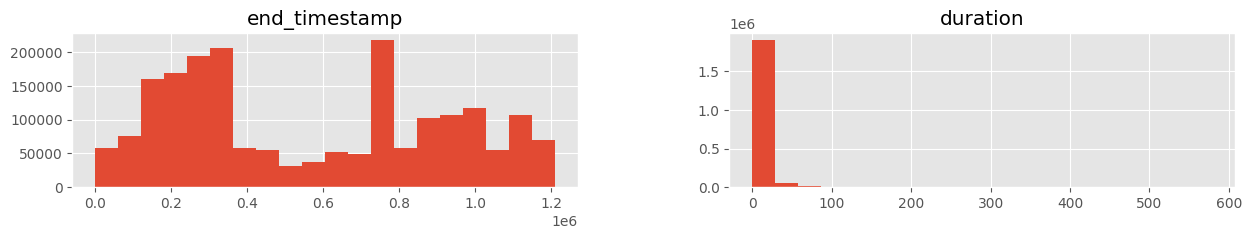

In [4]:
df.hist(column=["end_timestamp", "duration"], layout=[1, 2], figsize=[15, 2], bins=20)
plt.show()

# Duration distribution

In [5]:
def get_cdf(df, field):
    vals = sorted(df[field].values)
    invs = 100.0 * np.arange(0, len(df)) / len(df)
    return vals, invs

In [6]:
def plt_cdf(df, field="duration", title="Duration"):
    
    df_tokens, df_inv = get_cdf(df, field)
    plt.plot(df_tokens, df_inv)
    plt.title(title)
    plt.ylabel("CDF")
    plt.xlabel("Duration")
    plt.grid()
    plt.show()

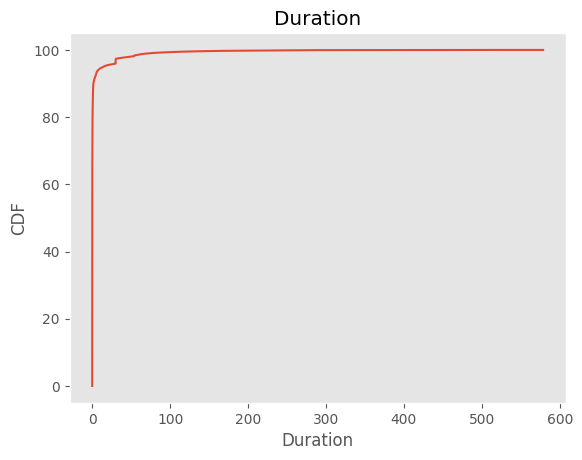

In [7]:
plt_cdf(df, field="duration")

In [8]:
print(f"unique apps: {df["app"].nunique()}, unique funcs: {df["func"].nunique()}")
# df.groupby("app")["func"].count() # num of times an app is invoked
fndf = df.groupby("func")["app"].count() # num of times a function is invoked
print(fndf.sort_values())

unique apps: 119, unique funcs: 424
func
858da1f388d3bf6686711777749d40d0a5289a187fce62a8f3ad4887cb559b5a         1
e374917dc55ed7244e36f36d40cfb4d00d586f22802986acbe4c964ef506dd67         1
1e7621e92fd24b589f58b7a1cca543d9c9090ef7eec6c155414f104a61c0b5fb         1
2038eb6547255afee8270d6fe4cdde5ca4c2f9f7e5a16fab3829c11dc9bf5198         1
20cc9adaa0894d35ec28d26a065d62693ce58ef36543078dd74ef48385d443e2         1
                                                                     ...  
bd5be891d0d10fbc3c59215d5f8159ea496433bc41adba7d8d10ea21d35c3e3a    116130
4753d9ffc8a362eadfb27498581969561c0ddbec7257759dbcb9936e506aff82    124143
cc5bb2108cc7daf53f9728ad21f661a8ef9c8b36284bacfcb712e2be87eef842    142856
8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f476e3914cae25bd2aae    212755
155e47f8e7f751d0c845049456d01832013c61336a8cd85901330ac821a71534    535667
Name: app, Length: 424, dtype: int64


In [9]:
### Invocation count bins

## Each `(app, func)` is assigned to one of five quintiles by total invocation count; table below summarizes each bin.

In [10]:
from forecast_eval import summarize_invocation_count_bins

per_function, bin_summary = summarize_invocation_count_bins(df, n_bins=5)
bin_summary

,bin,n_functions,inv_count_min,inv_count_max,inv_count_mean,inv_count_median,total_invocations,mean_duration,median_duration,mean_total_duration,pct_invocations,pct_functions
0,Q1,94,1,3,1.872340,2.0,176,5.299863,0.59175,9.411064,0.008885,22.169811
1,Q2,78,4,10,5.871795,5.0,458,10.937453,0.48475,58.199615,0.023120,18.396226
2,Q3,82,11,104,38.512195,30.0,3158,7.500094,0.43150,424.221793,0.159418,19.339623
3,Q4,85,105,1029,480.376471,343.0,40832,9.879576,0.25100,3535.413047,2.061232,20.047170
4,Q5,85,1062,535667,22780.317647,5172.0,1936327,13.740278,0.59600,74016.373776,97.747345,20.047170


In [23]:
df_s = df[["func", "start_timestamp"]]
df2 = df_s.loc[df_s["func"] == trace]
df_max = df_s.loc[df_s["func"] == t_max]

# date from Azure GH
df2["start_timestamp"] = pd.to_datetime(df2["start_timestamp"], origin="2021-01-31", unit="s")
df2 = df2.set_index("start_timestamp")

dfc = df2.resample("5min").count()
dfc = dfc.reset_index()
print(dfc)

        start_timestamp  func
0   2021-01-31 00:00:00     8
1   2021-01-31 00:05:00     8
2   2021-01-31 00:10:00     8
3   2021-01-31 00:15:00     8
4   2021-01-31 00:20:00     8
..                  ...   ...
624 2021-02-02 04:00:00    10
625 2021-02-02 04:05:00    14
626 2021-02-02 04:10:00    12
627 2021-02-02 04:15:00    11
628 2021-02-02 04:20:00     8

[629 rows x 2 columns]


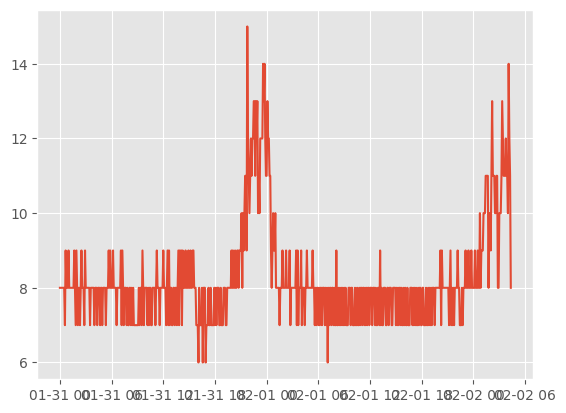

In [24]:
plt.style.use('ggplot')
plt.plot(dfc['start_timestamp'], dfc['func'])

In [25]:
df_max["start_timestamp"] = pd.to_datetime(df_max["start_timestamp"], unit="s")
df_max = df_max.set_index("start_timestamp")

dfc_max = df_max.resample("5min").count()
dfc_max = df_max.reset_index()
print(dfc_max)

                     start_timestamp  \
0      1970-01-01 01:47:09.368362011   
1      1970-01-01 01:47:10.616194014   
2      1970-01-01 01:47:10.960727900   
3      1970-01-01 01:47:12.308424992   
4      1970-01-01 01:47:12.589627909   
...                              ...   
535662 1970-01-14 23:59:56.700016903   
535663 1970-01-14 23:59:58.190409111   
535664 1970-01-14 23:59:58.560518908   
535665 1970-01-14 23:59:58.627381968   
535666 1970-01-14 23:59:59.693463969   

                                                     func  
0       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
1       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
2       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
3       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
4       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
...                                                   ...  
535662  155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
535663  155e47f8e7f751d0c845049456d0183

## Forecast evaluation

Holdout evaluation with MAE and RMSE via `forecast_eval.py` (baselines, ARIMA, Prophet). Exploratory Prophet/ARIMA cells below use the same trace but are not part of the holdout runner.

In [26]:
from forecast_eval import (
    build_invocation_series,
    default_forecasters,
    evaluate_trace,
    summarize_results,
    temporal_split,
    plot_holdout,
    evaluate_series,
    top_function_keys,
)

# Top functions by invocation volume (includes t_max workload)
top_keys = top_function_keys(df, n=5)
print(f"Evaluating {len(top_keys)} functions")

forecasters = default_forecasters(freq="5min")
results = evaluate_trace(
    df,
    forecasters,
    freq="5min",
    keys=top_keys,
)

summarize_results(results)

Evaluating 5 functions


16:10:52 - cmdstanpy - INFO - Chain [1] start processing
16:10:52 - cmdstanpy - INFO - Chain [1] done processing
16:10:52 - cmdstanpy - INFO - Chain [1] start processing
16:10:53 - cmdstanpy - INFO - Chain [1] done processing
16:10:53 - cmdstanpy - INFO - Chain [1] start processing
16:10:53 - cmdstanpy - INFO - Chain [1] done processing
16:10:53 - cmdstanpy - INFO - Chain [1] start processing
16:10:53 - cmdstanpy - INFO - Chain [1] done processing
16:10:54 - cmdstanpy - INFO - Chain [1] start processing
16:10:54 - cmdstanpy - INFO - Chain [1] done processing


,model,mae_mean,mae_median,rmse_mean,rmse_median,n_functions
3,prophet,121.584394,102.920584,329.227515,169.327440,5
4,seasonal_naive,133.929892,123.316314,360.650168,206.743974,5
1,moving_average_w12,143.201352,96.042756,350.469421,176.481287,5
2,naive,230.972324,94.988792,438.634675,178.406235,5
0,arima_2_1_2,248.517261,124.720409,443.108978,150.950476,5


15:02:08 - cmdstanpy - INFO - Chain [1] start processing
15:02:09 - cmdstanpy - INFO - Chain [1] done processing
15:02:09 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
15:02:09 - cmdstanpy - INFO - Chain [1] start processing


                     ds   y
0   2021-01-31 00:00:00   8
1   2021-01-31 00:05:00   8
2   2021-01-31 00:10:00   8
3   2021-01-31 00:15:00   8
4   2021-01-31 00:20:00   8
..                  ...  ..
624 2021-02-02 04:00:00  10
625 2021-02-02 04:05:00  14
626 2021-02-02 04:10:00  12
627 2021-02-02 04:15:00  11
628 2021-02-02 04:20:00   8

[629 rows x 2 columns]


15:02:09 - cmdstanpy - INFO - Chain [1] done processing


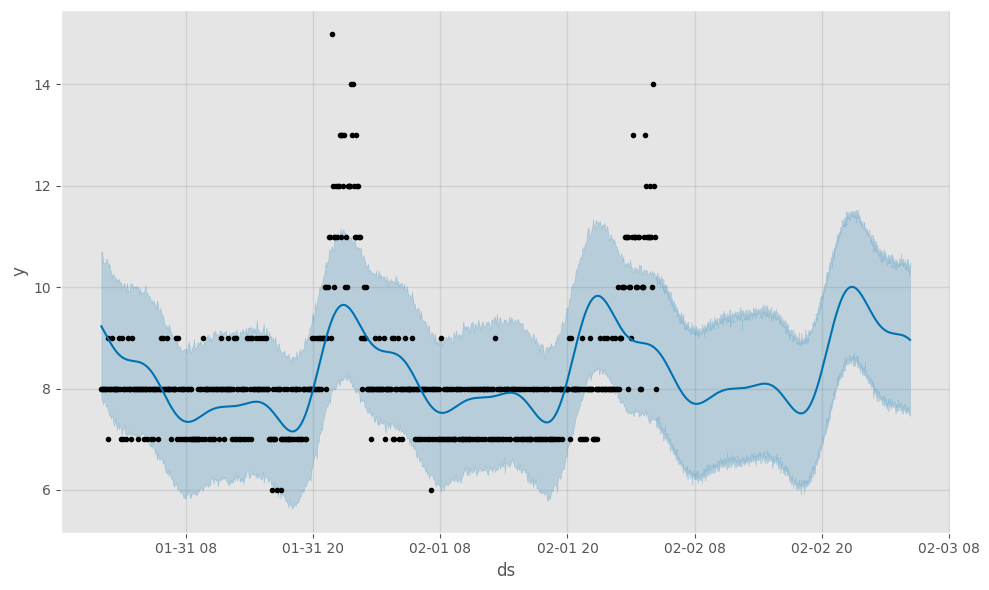

In [12]:
# Specifying the changepoint brings down the trend line at the end
m = Prophet(changepoints='2021-01-31')

dfp = dfc.rename(columns={"start_timestamp": "ds", "func": "y"})

print(dfp)
m.fit(dfp)

future = m.make_future_dataframe(periods=24*60, freq='min')
future.tail()

forecast = m.predict(future)

fig1 = m.plot(forecast)


In [ ]:
m.plot_components(forecast)

In [14]:
from statsmodels.tsa.arima.model import ARIMA


class FunctionInvocationPredictor:
    def __init__(self, freq="1min", arima_order=(3, 1, 2)):
        """
        freq: aggregation window
        arima_order: (p,d,q)
        """
        self.freq = freq
        self.order = arima_order
        self.models = {}

    def preprocess(self, df):
        """
        Convert raw invocation records into time series counts.
        """
        df = df.copy()

        # convert unix seconds -> datetime
        df["datetime"] = pd.to_datetime(df["end_timestamp"], unit="s")

        # bucket into fixed intervals
        df["bucket"] = df["datetime"].dt.floor(self.freq)

        # count invocations
        counts = (
            df.groupby(["app", "func", "bucket"])
            .size()
            .reset_index(name="count")
        )

        return counts

    def fit(self, df):
        """
        Train one ARIMA model per (app, func).
        """
        counts = self.preprocess(df)

        for (app, func), group in counts.groupby(["app", "func"]):
            ts = (
                group.set_index("bucket")["count"]
                .asfreq(self.freq, fill_value=0)
                .sort_index()
            )

            # need enough history
            if len(ts) < 20:
                continue

            try:
                model = ARIMA(ts, order=self.order)
                fitted = model.fit()

                self.models[(app, func)] = {
                    "model": fitted,
                    "history": ts
                }

                print(f"trained: {app} / {func}")

            except Exception as e:
                print(f"failed: {app} / {func}: {e}")

    def predict(self, app, func, steps=10):
        """
        Forecast future invocation counts.
        """
        key = (app, func)

        if key not in self.models:
            raise ValueError(f"No model for {app} / {func}")

        fitted = self.models[key]["model"]
        forecast = fitted.forecast(steps=steps)

        return forecast.clip(lower=0).round().astype(int)

    def plot_forecast(self, app, func, steps=10):
        """
        Plot historical + forecast.
        """
        key = (app, func)

        if key not in self.models:
            raise ValueError(f"No model for {app} / {func}")

        history = self.models[key]["history"]
        forecast = self.predict(app, func, steps)

        future_index = pd.date_range(
            start=history.index[-1] + pd.Timedelta(self.freq),
            periods=steps,
            freq=self.freq
        )

        plt.figure(figsize=(12, 5))
        plt.plot(history.index, history.values, label="history")
        plt.plot(future_index, forecast.values, label="forecast")
        plt.legend()
        plt.title(f"Invocation Forecast: {app} / {func}")
        plt.show()

In [15]:
# sample raw trace data
df = pd.DataFrame({
    "app": ["a1"] * 1000,
    "func": ["f1"] * 1000,
    "end_timestamp": np.random.randint(
        1715000000,
        1715000000 + 3600,
        1000
    ),
    "duration": np.random.rand(1000)
})

predictor = FunctionInvocationPredictor(
    freq="1min",
    arima_order=(2, 1, 2)
)

predictor.fit(df)

forecast = predictor.predict("a1", "f1", steps=15)

print(forecast)

trained: a1 / f1
2024-05-06 13:54:00    15
2024-05-06 13:55:00    18
2024-05-06 13:56:00    15
2024-05-06 13:57:00    17
2024-05-06 13:58:00    16
2024-05-06 13:59:00    17
2024-05-06 14:00:00    16
2024-05-06 14:01:00    17
2024-05-06 14:02:00    16
2024-05-06 14:03:00    17
2024-05-06 14:04:00    16
2024-05-06 14:05:00    17
2024-05-06 14:06:00    16
2024-05-06 14:07:00    17
2024-05-06 14:08:00    16
Freq: min, Name: predicted_mean, dtype: int64


/Users/jori/Projects/thesis/thesis-env/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
results

In [ ]:
# Holdout plot for the busiest function
if not results.empty:
    app, func = top_keys[0]
    series = build_invocation_series(df, freq="5min")[app, func]
    split = temporal_split(series)
    ev = evaluate_series(split.train, split.test, baselines[1])
    plot_holdout(split, ev["y_pred"], title=f"{app[:8]}… / {func[:8]}… ({ev['model']})")
    plt.show()